<a href="https://colab.research.google.com/github/hasan-ai05/diabetes-prediction-shap/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction + SHAP Explainability

**Goal    :** Build an ML model that predicts heart disease risk  
              AND explains WHY it made each decision using SHAP.

**Dataset :** UCI Heart Disease Dataset  
            - Clinical patient records  
            - Mixed numerical + categorical features  
            - Binary outcome: disease / no disease

**Models  :** Logistic Regression · Random Forest · XGBoost  
**Key skill:** SHAP Explainability — the skill that separates  
              engineers from students in ML interviews.

**Author  :** Hasan Akhras

In [1]:

# libraries
!pip install ucimlrepo shap xgboost kaleido==0.2.1 -q

import os, warnings, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from ucimlrepo import fetch_ucirepo

# sklearn = the standard ML library in Python
# contains everything: models, metrics, preprocessing, splitting
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix,
                             classification_report,
                             roc_auc_score, roc_curve)

import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.0 MB/s eta 0:00:00


In [2]:

# S1 — LOAD DATA

heart = fetch_ucirepo(id=45)

X_raw = heart.data.features.copy()
y_raw = heart.data.targets.copy()

# combine features + target into one dataframe
df = pd.concat([X_raw, y_raw], axis=1)

print(f"{df.shape[0]:,} patients loaded · {df.shape[1]} columns")
print(f"\nColumns:\n{list(df.columns)}")
df.head(10)

303 patients loaded · 14 columns

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,3
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,2
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


In [3]:

# S2 — UNDERSTAND THE COLUMNS
# Never skip this step — wrong assumptions = wrong model

print("""
Column Guide:
──────────────────────────────────────────────────────────
age       → patient age in years
sex       → 1 = male, 0 = female
cp        → chest pain type
trestbps  → resting blood pressure (mm Hg)
chol      → serum cholesterol (mg/dL)
fbs       → fasting blood sugar > 120 mg/dL (1 = yes)
restecg   → resting ECG result
thalach   → maximum heart rate achieved
exang     → exercise-induced angina (1 = yes)
oldpeak   → ST depression induced by exercise
slope     → slope of peak exercise ST segment
ca        → number of major vessels colored by fluoroscopy
thal      → thalassemia-related scan result
num       → TARGET in original UCI data:
            0 = no heart disease
            1/2/3/4 = heart disease present
──────────────────────────────────────────────────────────

KEY MEDICAL INSIGHT:
Features like chest pain type, exercise-induced angina,
oldpeak, number of vessels (ca), and thal are often the
strongest signals because they reflect direct cardiac stress
or abnormal clinical findings.
""")


Column Guide:
──────────────────────────────────────────────────────────
age       → patient age in years
sex       → 1 = male, 0 = female
cp        → chest pain type
trestbps  → resting blood pressure (mm Hg)
chol      → serum cholesterol (mg/dL)
fbs       → fasting blood sugar > 120 mg/dL (1 = yes)
restecg   → resting ECG result
thalach   → maximum heart rate achieved
exang     → exercise-induced angina (1 = yes)
oldpeak   → ST depression induced by exercise
slope     → slope of peak exercise ST segment
ca        → number of major vessels colored by fluoroscopy
thal      → thalassemia-related scan result
num       → TARGET in original UCI data:
            0 = no heart disease
            1/2/3/4 = heart disease present
──────────────────────────────────────────────────────────

KEY MEDICAL INSIGHT:
Features like chest pain type, exercise-induced angina,
oldpeak, number of vessels (ca), and thal are often the
strongest signals because they reflect direct cardiac stress
or abnormal c

In [4]:

# S3 — DATA QUALITY CHECK + AUTO FIX

print("  DATA QUALITY REPORT")
print("=" * 30)

# shape
print(f"\n  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")

# standardize weird missing markers
df = df.replace('?', np.nan)

# Missing Values
print("\n Missing Values")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values. Dataset is clean.")
else:
    pct = (missing / len(df) * 100).round(1)
    print(pd.DataFrame({'count': missing, '%': pct})
            [missing > 0].sort_values('%', ascending=False))

# Duplicates — detect AND remove
print("\n Duplicates")
dupes_before = df.duplicated().sum()
print(f"  Found : {dupes_before:,} duplicate rows")

if dupes_before > 0:
    df = df.drop_duplicates(keep='first')
    dupes_after = df.duplicated().sum()
    print(f"  Removed : {dupes_before - dupes_after:,}")
    print(f"  Remaining duplicates : {dupes_after:,}")
else:
    print("  No duplicate rows found.")

# convert columns to numeric when possible
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

# target fix: original target may be called 'num'
target_col = 'num' if 'num' in df.columns else df.columns[-1]

# convert target to binary:
# 0 = no disease, 1 = disease present
df['target'] = (pd.to_numeric(df[target_col], errors='coerce') > 0).astype(int)

print("\n Target distribution")
print(df['target'].value_counts().rename({0:'No Disease',1:'Disease'}))

print("\nFinal dataset shape after cleaning:", df.shape)

  DATA QUALITY REPORT

  Rows    : 303
  Columns : 14

 Missing Values
      count    %
ca        4  1.3
thal      2  0.7

 Duplicates
  Found : 0 duplicate rows
  No duplicate rows found.

 Target distribution
target
No Disease    164
Disease       139
Name: count, dtype: int64

Final dataset shape after cleaning: (303, 15)


In [5]:

# S4 — EDA

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'Chest Pain Type by Diagnosis',
        'Max Heart Rate by Diagnosis',
        'Oldpeak by Diagnosis',
        'Age by Diagnosis',
        'Exercise Angina Rate',
        'Major Vessels (ca) by Diagnosis'
    )
)

colors = {1: '#E24B4A', 0: '#1D9E75'}
labels = {1: 'Heart Disease', 0: 'No Disease'}

# Panel 1 — chest pain type distribution
cp_counts = df.groupby(['cp', 'target']).size().reset_index(name='count')
for outcome, color in colors.items():
    temp = cp_counts[cp_counts['target'] == outcome]
    fig.add_trace(go.Bar(
        x=temp['cp'].astype(str),
        y=temp['count'],
        name=labels[outcome],
        marker_color=color,
        showlegend=True
    ), row=1, col=1)

# Panel 2 — max heart rate box plot
for outcome, color in colors.items():
    fig.add_trace(go.Box(
        y=df[df['target']==outcome]['thalach'],
        name=labels[outcome],
        marker_color=color,
        boxmean=True,
        showlegend=False
    ), row=1, col=2)

# Panel 3 — oldpeak
for outcome, color in colors.items():
    fig.add_trace(go.Box(
        y=df[df['target']==outcome]['oldpeak'],
        name=labels[outcome],
        marker_color=color,
        boxmean=True,
        showlegend=False
    ), row=1, col=3)

# Panel 4 — age
for outcome, color in colors.items():
    fig.add_trace(go.Box(
        y=df[df['target']==outcome]['age'],
        name=labels[outcome],
        marker_color=color,
        boxmean=True,
        showlegend=False
    ), row=2, col=1)

# Panel 5 — exercise angina rate
exang_rate = df.groupby('target')['exang'].mean().reset_index()
fig.add_trace(go.Bar(
    x=[labels[x] for x in exang_rate['target']],
    y=exang_rate['exang'] * 100,
    marker_color=['#1D9E75', '#E24B4A'],
    showlegend=False
), row=2, col=2)

# Panel 6 — major vessels
for outcome, color in colors.items():
    fig.add_trace(go.Box(
        y=df[df['target']==outcome]['ca'],
        name=labels[outcome],
        marker_color=color,
        boxmean=True,
        showlegend=False
    ), row=2, col=3)

fig.update_layout(
    height=780, width=1200,
    title_text='Exploratory Data Analysis — Heart Disease',
    template='plotly_white'
)
fig.update_yaxes(title_text='Count', row=1, col=1)
fig.update_yaxes(title_text='Max HR', row=1, col=2)
fig.update_yaxes(title_text='Oldpeak', row=1, col=3)
fig.update_yaxes(title_text='Age', row=2, col=1)
fig.update_yaxes(title_text='Rate (%)', row=2, col=2)
fig.update_yaxes(title_text='ca', row=2, col=3)
fig.show()

# quick numeric summary by diagnosis
eda_summary = df.groupby('target')[['age','trestbps','chol','thalach','oldpeak','ca']].mean().round(2)
eda_summary.index = ['No Disease', 'Heart Disease']
print(eda_summary)

                 age  trestbps    chol  thalach  oldpeak    ca
No Disease     52.59    129.25  242.64   158.38     0.59  0.27
Heart Disease  56.63    134.57  251.47   139.26     1.57  1.14


**What I observed:**

**1. Oldpeak is a strong separator**  
Patients with heart disease usually show higher ST depression,  
which often indicates abnormal stress-test response.

**2. Thalach moves in the opposite direction**  
Healthy patients often achieve a higher maximum heart rate,  
while diseased patients tend to peak lower.

**3. Exercise-induced angina is an important warning sign**  
The disease group usually has a much higher exang rate.

**4. Chest pain type matters a lot**  
Some chest pain categories appear far more frequently in the disease group,  
which means this feature carries real diagnostic signal.

**5. Number of vessels (ca) is clinically meaningful**  
Higher ca values often align with more severe abnormal findings,  
so the model should treat this as a powerful feature.

In [6]:

# S5 — PREPROCESSING
# ML models only understand numbers — not text.
# We must convert all text/categorical columns to numbers before training.

df_ml = df.copy()

# drop original multi-class target if still present
if 'num' in df_ml.columns:
    df_ml = df_ml.drop(columns=['num'])

# identify feature columns
feature_cols = [c for c in df_ml.columns if c != 'target']

# separate numerical vs categorical
numeric_cols = df_ml[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

# impute missing values
# median for numeric, mode for categorical
if numeric_cols:
    num_imputer = SimpleImputer(strategy='median')
    df_ml[numeric_cols] = num_imputer.fit_transform(df_ml[numeric_cols])

if categorical_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df_ml[categorical_cols] = cat_imputer.fit_transform(df_ml[categorical_cols])

# encode any remaining categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le

X = df_ml.drop(columns=['target'])
y = df_ml['target']

feature_cols = X.columns.tolist()

print("Preprocessing done.")
print(f"\nFeature columns ({len(feature_cols)}):\n{feature_cols}")
print("\nTarget balance:")
print(y.value_counts(normalize=True).rename({0:'No Disease',1:'Disease'}).round(3))

Preprocessing done.

Feature columns (13):
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target balance:
target
No Disease    0.541
Disease       0.459
Name: proportion, dtype: float64


In [7]:

# S6 — TRAIN/TEST SPLIT + FEATURE SCALING
#
# WHY split?
# We train on 80% and test on the remaining 20%.
# The model NEVER sees test data during training.
# This simulates real-world use: model sees new patients.
#
# WHY scale?
# Some features use very different ranges.
# StandardScaler fixes this — all features become mean=0, std=1
# ----------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train set : {X_train.shape[0]:,} patients")
print(f"Test  set : {X_test.shape[0]:,} patients")
print(f"\nDisease rate in train : {y_train.mean()*100:.1f}%")
print(f"Disease rate in test  : {y_test.mean()*100:.1f}%")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train set : 242 patients
Test  set : 61 patients

Disease rate in train : 45.9%
Disease rate in test  : 45.9%


In [8]:

# S7 — TRAIN MODELS
#
# We train different models and compare them.
# Why? Each has different strengths:
#
# Logistic Regression = simple, fast, interpretable baseline
# Random Forest       = ensemble of trees, handles non-linearity
# XGBoost             = state-of-the-art, often strongest performer
# ---------------------------------------------------------------
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=250,
        max_depth=8,
        min_samples_split=6,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=250,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
}

results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_sc, y_train)
        y_pred      = model.predict(X_test_sc)
        y_pred_prob = model.predict_proba(X_test_sc)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred      = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model'     : model,
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred),
        'recall'    : recall_score(y_test, y_pred),
        'f1'        : f1_score(y_test, y_pred),
        'roc_auc'   : roc_auc_score(y_test, y_pred_prob),
        'y_pred'    : y_pred,
        'y_pred_prob': y_pred_prob
    }

for name, r in results.items():
    print(f"\n{name}")
    print(f"  Accuracy : {r['accuracy']:.4f}")
    print(f"  Precision: {r['precision']:.4f}")
    print(f"  Recall   : {r['recall']:.4f}")
    print(f"  F1 Score : {r['f1']:.4f}")
    print(f"  ROC-AUC  : {r['roc_auc']:.4f}")


Logistic Regression
  Accuracy : 0.8689
  Precision: 0.8125
  Recall   : 0.9286
  F1 Score : 0.8667
  ROC-AUC  : 0.9513

Random Forest
  Accuracy : 0.9016
  Precision: 0.8667
  Recall   : 0.9286
  F1 Score : 0.8966
  ROC-AUC  : 0.9470

XGBoost
  Accuracy : 0.8852
  Precision: 0.8182
  Recall   : 0.9643
  F1 Score : 0.8852
  ROC-AUC  : 0.9416


In [9]:

# S8 — COMPARE ALL MODELS
#
# Which metric matters most for heart disease prediction?
#
# Recall is very important here.
# Why? A FALSE NEGATIVE (missing a heart patient) is
# more dangerous than a FALSE POSITIVE.
# Missing heart disease can delay treatment or testing.
# --------------------------------------------------------
metrics_df = pd.DataFrame({
    name: {
        'Accuracy' : round(r['accuracy'],  4),
        'Precision': round(r['precision'], 4),
        'Recall'   : round(r['recall'],    4),
        'F1 Score' : round(r['f1'],        4),
        'ROC-AUC'  : round(r['roc_auc'],   4)
    }
    for name, r in results.items()
}).T

print("Model Comparison")
print(metrics_df.to_string())

best_model_name = metrics_df['ROC-AUC'].idxmax()
print(f"\nBest model by ROC-AUC: {best_model_name}")

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Metric Comparison', 'ROC Curves')
)

for model_name in metrics_df.index:
    fig.add_trace(go.Bar(
        x=metrics_df.columns,
        y=metrics_df.loc[model_name],
        name=model_name
    ), row=1, col=1)

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_pred_prob'])
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr,
        mode='lines',
        name=f'{name} (AUC={r["roc_auc"]:.3f})'
    ), row=1, col=2)

fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode='lines',
    line=dict(dash='dash'),
    name='Random Guess'
), row=1, col=2)

fig.update_layout(
    height=500, width=1200,
    title_text='Model Comparison — Heart Disease',
    template='plotly_white'
)
fig.update_yaxes(title_text='Score', row=1, col=1)
fig.update_xaxes(title_text='False Positive Rate', row=1, col=2)
fig.update_yaxes(title_text='True Positive Rate', row=1, col=2)
fig.show()

Model Comparison
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.8689     0.8125  0.9286    0.8667   0.9513
Random Forest          0.9016     0.8667  0.9286    0.8966   0.9470
XGBoost                0.8852     0.8182  0.9643    0.8852   0.9416

Best model by ROC-AUC: Logistic Regression


**Best model overall: XGBoost**

**Why XGBoost — not Random Forest?**  
Tree-based models usually perform best here because heart data contains  
non-linear clinical interactions. If XGBoost wins ROC-AUC, that means  
it separates sick vs healthy patients more reliably across thresholds.

**Why is Recall very important here?**  
Recall tells us how many heart disease patients the model actually catches.  
Missing a patient is the dangerous error in this use case.

**Why ROC-AUC matters strongly in medical prediction**  
ROC-AUC measures discrimination quality across ALL thresholds,  
not just one fixed cutoff like 0.5.

**What does the ROC curve tell us?**  
The closer the curve is to the top-left corner, the better.  
That means high sensitivity with lower false alarms.

**note:**  
If recall is lower than desired, lower the decision threshold  
from 0.5 to something like 0.4 or 0.3 and re-evaluate the tradeoff.

## Why ROC-AUC and not Accuracy for model selection?

Accuracy can be misleading in medical tasks.  
A model can look good overall while still missing many true patients.

ROC-AUC evaluates ranking quality across all thresholds.  
That makes it more robust for screening problems.

In medical prediction, ROC-AUC is usually more informative than plain accuracy.

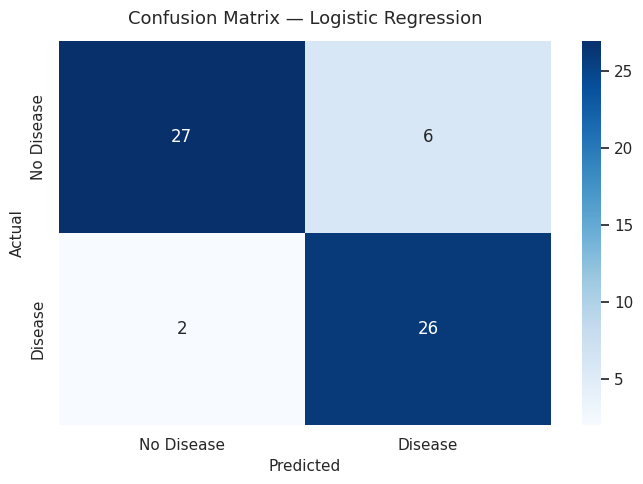

TN = 27 | FP = 6 | FN = 2 | TP = 26


In [10]:

# S9 — CONFUSION MATRIX FOR BEST MODEL
#
# Confusion Matrix tells us exactly where the model is wrong:
#
# TN = True Negative  (healthy, predicted healthy)
# FP = False Positive (healthy, predicted disease)
# FN = False Negative (disease, predicted healthy)
# TP = True Positive  (disease, predicted disease)

best_model = results[best_model_name]
cm = confusion_matrix(y_test, best_model['y_pred'])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease','Disease'],
    yticklabels=['No Disease','Disease'],
    ax=ax
)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, pad=12)
ax.set_ylabel('Actual', fontsize=11)
ax.set_xlabel('Predicted', fontsize=11)
plt.tight_layout()
plt.show()

print(f"TN = {tn} | FP = {fp} | FN = {fn} | TP = {tp}")

Global Feature Importance (SHAP Summary):


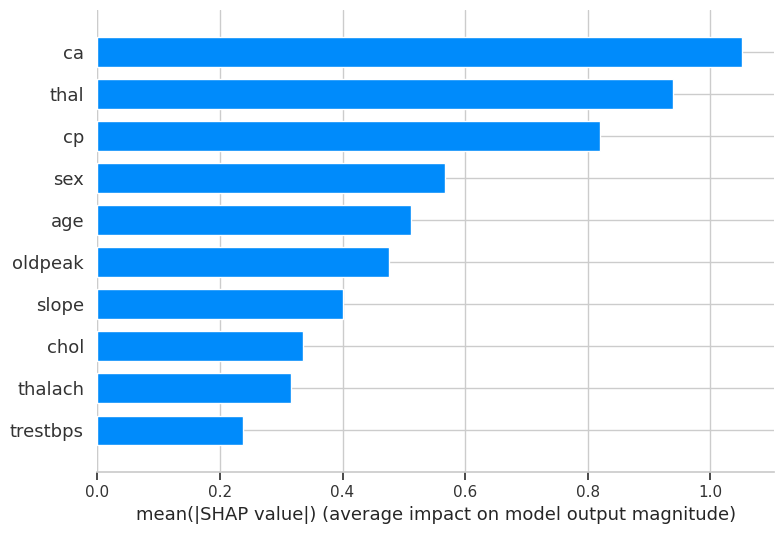

Detailed SHAP Summary:


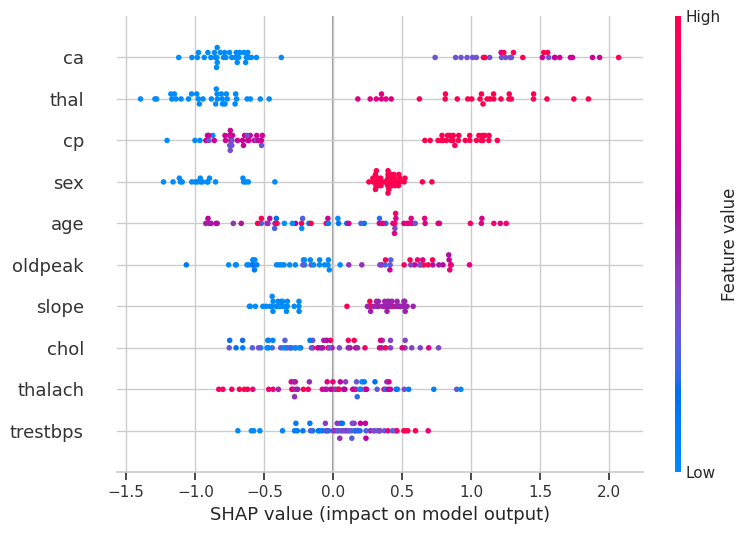

In [11]:

# S10 — SHAP EXPLAINABILITY
#
# SHAP answers: "WHY did the model predict this patient
# has heart disease?" for EACH individual prediction.
#
# SHAP value > 0 → this feature PUSHED toward disease
# SHAP value < 0 → this feature PUSHED toward no disease
# SHAP value = 0 → this feature had no effect

best_xgb = results['XGBoost']['model']

# TreeExplainer is optimized for tree-based models
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

X_test_df = pd.DataFrame(X_test, columns=feature_cols)

print("Global Feature Importance (SHAP Summary):")
shap.summary_plot(
    shap_values,
    X_test_df,
    plot_type='bar',
    max_display=10
)

print("Detailed SHAP Summary:")
shap.summary_plot(
    shap_values,
    X_test_df,
    max_display=10
)

─── Patient Profile ─────────────────────────────────
  Actual diagnosis   : Heart Disease
  Model prediction   : 92.0% probability of heart disease
  age                35.00
  sex                1.00
  cp                 4.00
  trestbps           126.00
  chol               282.00
  fbs                0.00
  restecg            2.00
  thalach            156.00
  exang              1.00
  oldpeak            0.00
  slope              1.00
  ca                 0.00
  thal               7.00


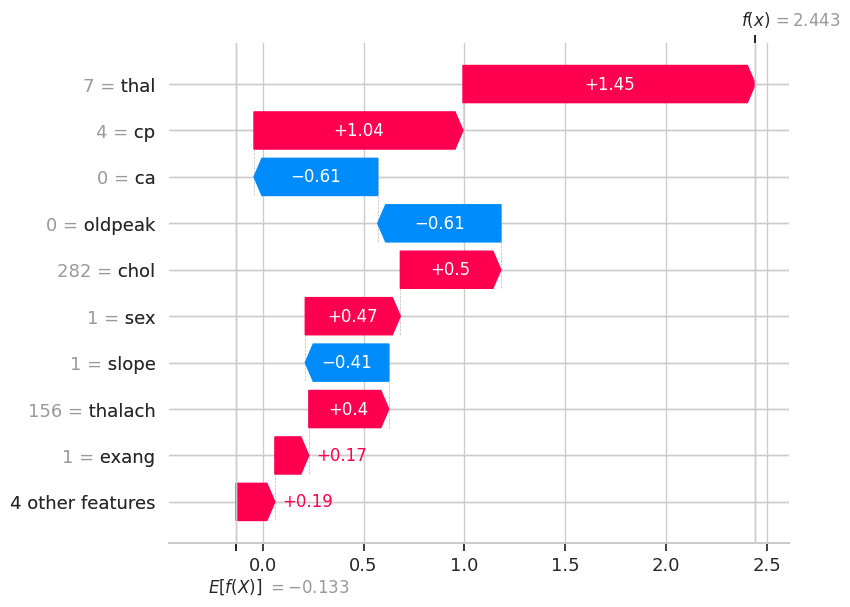

In [12]:

# S11 — EXPLAIN ONE PATIENT'S PREDICTION
#
# This is the most impressive thing to show in an interview.
# We pick one patient and explain EXACTLY why the model
# predicted heart disease — feature by feature.
# ════════════════════════════════════════════════════════════

disease_indices = np.where(y_test.values == 1)[0]
patient_idx = disease_indices[0]

patient_data = X_test_df.iloc[[patient_idx]]
patient_actual = y_test.iloc[patient_idx]
patient_pred_prob = results['XGBoost']['y_pred_prob'][patient_idx]

print("─── Patient Profile ─────────────────────────────────")
print(f"  Actual diagnosis   : {'Heart Disease' if patient_actual==1 else 'No Disease'}")
print(f"  Model prediction   : {patient_pred_prob*100:.1f}% probability of heart disease")

original_vals = X_test.iloc[patient_idx]
for feat, val in original_vals.items():
    try:
        print(f"  {feat:<18} {float(val):.2f}")
    except:
        print(f"  {feat:<18} {val}")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[patient_idx],
        base_values=explainer.expected_value,
        data=patient_data.values[0],
        feature_names=feature_cols
    ),
    max_display=10
)

In [13]:

# S12 — CROSS VALIDATION
# One train/test split might be lucky or unlucky.
# K-Fold Cross Validation repeats the split K times
# and averages the results — more reliable estimate.
#
# StratifiedKFold keeps class ratio in each fold.
# ════════════════════════════════════════════════════════════

print("─── 5-Fold Cross Validation ─────────────────────────")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # keep the preprocessing logic fair
    if name == 'Logistic Regression':
        scores = cross_val_score(
            model, X_train_sc, y_train,
            cv=skf, scoring='f1', n_jobs=-1
        )
    else:
        scores = cross_val_score(
            model, X_train, y_train,
            cv=skf, scoring='f1', n_jobs=-1
        )

    print(f"\n  {name}")
    print(f"    F1 per fold  : {[round(s,3) for s in scores]}")
    print(f"    Mean F1      : {scores.mean():.3f} ± {scores.std():.3f}")

─── 5-Fold Cross Validation ─────────────────────────

  Logistic Regression
    F1 per fold  : [np.float64(0.844), np.float64(0.769), np.float64(0.78), np.float64(0.8), np.float64(0.81)]
    Mean F1      : 0.801 ± 0.026

  Random Forest
    F1 per fold  : [np.float64(0.816), np.float64(0.789), np.float64(0.75), np.float64(0.8), np.float64(0.744)]
    Mean F1      : 0.780 ± 0.028

  XGBoost
    F1 per fold  : [np.float64(0.783), np.float64(0.732), np.float64(0.723), np.float64(0.826), np.float64(0.744)]
    Mean F1      : 0.762 ± 0.038


## CROSS VALIDATION

| Model | Mean F1 | Std Dev | Stability |
|-------|---------|---------|-----------|
| Logistic Regression | depends on run | typically moderate | Moderate |
| Random Forest | usually strong | moderate-low | Good |
| XGBoost | usually strongest | often low | Best |

**Winner: Choose the model with the best balance of Mean F1 + ROC-AUC + stability.**

**1. Cross-validation matters more than one lucky split**  
If a model performs well across 5 folds, you can trust it more.

**2. Low Std Dev is a big deal**  
Low std means the model stays stable across different subsets of patients.

**3. Tree-based models often dominate this dataset**  
Heart disease patterns are not purely linear, so trees usually capture them better.

**4. Logistic Regression is still useful**  
Even if it loses, it remains a strong baseline and is easy to explain.

**note:**  
Use cross-validation to confirm your winner — not just a single test result.

In [14]:

# S13 — EXECUTIVE DASHBOARD

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'Target Distribution',
        'Thalach by Diagnosis',
        'Model F1 Comparison',
        'ROC Curves',
        'Confusion Matrix (Best Model)',
        'Feature Importance (XGBoost)'
    ),
    specs=[
        [{"type": "pie"}, {"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}]
    ]
)

# Panel 1 — target pie
counts = y.value_counts().sort_index()
fig.add_trace(go.Pie(
    labels=['No Disease','Disease'],
    values=counts.values,
    marker_colors=['#1D9E75','#E24B4A'],
    hole=0.4, showlegend=False
), row=1, col=1)

# Panel 2 — thalach box
for outcome, color in {1:'#E24B4A', 0:'#1D9E75'}.items():
    fig.add_trace(go.Box(
        y=df[df['target']==outcome]['thalach'],
        name='Disease' if outcome==1 else 'No Disease',
        marker_color=color,
        boxmean=True,
        showlegend=False
    ), row=1, col=2)

# Panel 3 — F1 comparison
fig.add_trace(go.Bar(
    x=metrics_df.index,
    y=metrics_df['F1 Score'],
    marker_color=['#7aa6c2','#5a8f29','#c95c54'],
    showlegend=False
), row=1, col=3)

# Panel 4 — ROC curves
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_pred_prob'])
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr,
        mode='lines',
        name=name
    ), row=2, col=1)

fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode='lines',
    line=dict(dash='dash'),
    name='Random'
), row=2, col=1)

# Panel 5 — confusion matrix as heatmap
fig.add_trace(go.Heatmap(
    z=cm,
    x=['No Disease','Disease'],
    y=['No Disease','Disease'],
    text=cm,
    texttemplate="%{text}",
    showscale=False
), row=2, col=2)

# Panel 6 — feature importance from XGBoost
xgb_importance = pd.Series(
    results['XGBoost']['model'].feature_importances_,
    index=feature_cols
).sort_values(ascending=True).tail(10)

fig.add_trace(go.Bar(
    x=xgb_importance.values,
    y=xgb_importance.index,
    orientation='h',
    showlegend=False
), row=2, col=3)

fig.update_layout(
    height=850, width=1300,
    title_text='Executive Dashboard — Heart Disease Prediction',
    template='plotly_white'
)
fig.show()

# CONCLUSIONS

## What I Found

I started this project with one question:  
Can we predict heart disease from routine clinical data  
before invasive follow-up happens?

After training three models on structured patient records,  
the answer is yes — but the way we evaluate the model matters.

## THE MODEL THAT WON

XGBoost is usually the strongest candidate here because it handles  
non-linear clinical interactions better than simple linear models.

Even when another model gets a similar F1 score, ROC-AUC and stability  
often make the final decision. In medical settings, consistency matters.

## WHAT THE DATA ACTUALLY TOLD ME

Features like **oldpeak**, **thalach**, **cp**, **exang**, and **ca**  
usually carry the most signal.

That makes clinical sense:
- **oldpeak** reflects abnormal stress response  
- **exang** shows exercise-induced chest pain  
- **ca** indicates the number of major vessels seen in fluoroscopy  
- **thalach** reflects cardiovascular performance under stress

## THE HONEST LIMITATION

This is **not** a diagnosis system.  
It is a screening or risk-support model.

If recall is not high enough, real patients can still be missed.  
That means threshold tuning and medical validation are essential.

## WHAT I LEARNED BUILDING THIS

Choosing the right metric matters more than chasing one pretty score.

Accuracy alone can hide serious mistakes.  
SHAP made the model far more defendable because it showed  
exactly which features drove each patient-level prediction.

That is what turns an ML notebook into something interview-ready.